## Density Plots
Credit: https://github.com/serengil/deepface/blob/master/experiments/distance-to-confidence.ipynb

In [ ]:
! pip install deepface

# built-in dependencies
import itertools
import math, os

# 3rd party dependencies
import pandas as pd
from deepface import DeepFace
from deepface.modules.verification import find_distance, find_threshold
from tqdm import tqdm
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt

In [ ]:
detector_backend = "mtcnn" # a robust one

model_names = [
    "VGG-Face", "Facenet", "Facenet512", "ArcFace", "GhostFaceNet",
    "Dlib", "SFace", "OpenFace", "DeepFace", "DeepID", "Buffalo_L"
]

distance_metrics = [
    "cosine", "euclidean", "euclidean_l2"
]

In [ ]:
pd.set_option('display.max_rows', None)

model_name = model_names[1]

print(f"Running an experiment for {model_name} & {detector_backend}...")
# build models in advance
model = DeepFace.build_model(model_name)
detector = DeepFace.build_model(task="face_detector", model_name=detector_backend)

Running an experiment for Facenet & mtcnn...
25-12-15 17:35:59 - 🔗 facenet_weights.h5 will be downloaded from https://github.com/serengil/deepface_models/releases/download/v1.0/facenet_weights.h5 to /root/.deepface/weights/facenet_weights.h5...


Downloading...
From: https://github.com/serengil/deepface_models/releases/download/v1.0/facenet_weights.h5
To: /root/.deepface/weights/facenet_weights.h5
100%|██████████| 92.2M/92.2M [00:00<00:00, 116MB/s]


## **Preparing the images**

```py
identities = {
 "Angelina": ["img1.jpg", "img2.jpg", "img4.jpg"
    , "img5.jpg", "img6.jpg", "img7.jpg", "img10.jpg", "img11.jpg"],
 "Scarlett": ["img8.jpg", "img9.jpg"],
 "Jennifer": ["img3.jpg", "img12.jpg"],
 "Mark": ["img13.jpg", "img14.jpg", "img15.jpg"],
 "Jack": ["img16.jpg", "img17.jpg"],
 "Elon": ["img18.jpg", "img19.jpg"],
 "Jeff": ["img20.jpg", "img21.jpg"],
 "Marissa": ["img22.jpg", "img23.jpg"],
 "Sundar": ["img24.jpg", "img25.jpg"]
}
```

In [ ]:
# !unzip intra-sim.zip

In [ ]:
path = "intra-sim/"
identities = {}

for entry in os.listdir(path):
    person_collection = os.path.join(path, entry)

    if os.path.isdir(person_collection):
        identities[entry] = []
        for file_ in os.listdir(person_collection):
          identities[entry].append(str(entry+"/"+file_))

In [ ]:
positives = []
for key, values in identities.items():
 for i in range(0, len(values)-1):
  for j in range(i+1, len(values)):
   positive = []
   positive.append(values[i])
   positive.append(values[j])
   positives.append(positive)

positives = pd.DataFrame(positives, columns = ["file_x", "file_y"])
positives["actual"] = "Same Person"

#############

samples_list = list(identities.values())

negatives = []
for i in range(0, len(identities) - 1):
 for j in range(i+1, len(identities)):
  cross_product = itertools.product(samples_list[i], samples_list[j])
  cross_product = list(cross_product)

  for cross_sample in cross_product:
   negative = []
   negative.append(cross_sample[0])
   negative.append(cross_sample[1])
   negatives.append(negative)

negatives = pd.DataFrame(negatives, columns = ["file_x", "file_y"])
negatives["actual"] = "Different Persons"

#############

df = pd.concat([positives, negatives]).reset_index(drop = True)

df.file_x = "intra-sim/"+df.file_x
df.file_y = "intra-sim/"+df.file_y

In [ ]:
print(df.head())
df.shape

                          file_x                         file_y       actual
0  intra-sim/Hugo_Chavez_/13.png   intra-sim/Hugo_Chavez_/1.png  Same Person
1  intra-sim/Hugo_Chavez_/13.png   intra-sim/Hugo_Chavez_/7.png  Same Person
2  intra-sim/Hugo_Chavez_/13.png   intra-sim/Hugo_Chavez_/6.png  Same Person
3  intra-sim/Hugo_Chavez_/13.png  intra-sim/Hugo_Chavez_/10.png  Same Person
4  intra-sim/Hugo_Chavez_/13.png   intra-sim/Hugo_Chavez_/8.png  Same Person


(768180, 3)

## **Generate Embeddings**

In [ ]:
pivot = {}
def represent(img_name: str):
    if pivot.get(img_name) is None:
        embedding_objs = DeepFace.represent(img_path=img_name, model_name=model_name, detector_backend=detector_backend)

        if len(embedding_objs) > 1:
            print(f"{img_name} has more than one face!")
            embedding_objs = [embedding_objs[max(range(len(embedding_objs)), key=lambda index: embedding_objs[index]['face_confidence'])]]

        pivot[img_name] = [embedding_obj["embedding"] for embedding_obj in embedding_objs]
    return pivot[img_name]

img1_embeddings = []
img2_embeddings = []
for index, instance in tqdm(df.iterrows(), total=df.shape[0]):
  try:
    img1_embeddings = img1_embeddings + represent(instance["file_x"])
    img2_embeddings = img2_embeddings + represent(instance["file_y"])
  except ValueError as e:
    print(e)

  0%|          | 7/768180 [00:03<78:57:02,  2.70it/s]

intra-sim/Hugo_Chavez_/15.png has more than one face!


  0%|          | 13/768180 [00:06<97:40:00,  2.18it/s] 

intra-sim/Hugo_Chavez_/3.png has more than one face!


  0%|          | 16/768180 [00:07<81:41:07,  2.61it/s]

...

  1%|▏         | 11401/768180 [07:45<5:02:55, 41.64it/s] 

intra-sim/Jennifer_Capriati_/11.png has more than one face!


  2%|▏         | 11591/768180 [07:53<5:33:35, 37.80it/s] 

intra-sim/George_W_Bush_/8.png has more than one face!
intra-sim/George_W_Bush_/11.png has more than one face!


100%|██████████| 768180/768180 [36:57<00:00, 346.35it/s]


In [ ]:
df["img1_embeddings"] = img1_embeddings
df["img2_embeddings"] = img2_embeddings

## **Distance Calculation from embeddings, and classification**

In [ ]:
for distance_metric in distance_metrics:
    distances = []
    for index, instance in tqdm(df.iterrows(), total=df.shape[0]):
        img1_embeddings = instance["img1_embeddings"]
        img2_embeddings = instance["img2_embeddings"]

        distance = find_distance(
            alpha_embedding=img1_embeddings,
            beta_embedding=img2_embeddings,
            distance_metric=distance_metric
        )
        distances.append(distance)

    df[distance_metric] = distances

for distance_metric in distance_metrics:
    threshold = find_threshold(model_name=model_name, distance_metric=distance_metric)
    df[f"{distance_metric}_threshold"] = threshold
    df[f"{distance_metric}_decision"] = 0
    idx = df[df[distance_metric] <= threshold].index
    df.loc[idx, f"{distance_metric}_decision"] = 1

100%|██████████| 768180/768180 [01:28<00:00, 8718.27it/s]


## **Confidence Calculation**

In [ ]:
confidence_metrics = {}

for distance_metric in distance_metrics:
    max_value = df[distance_metric].max()

    X = df[distance_metric].values.reshape(-1, 1)

    # normalize the distance values before feeding them to the model
    if max_value > 1:
        X = X / max_value

    y = df[f"{distance_metric}_decision"].values

    model = LogisticRegression().fit(X, y)

    w = model.coef_[0][0]
    b = model.intercept_[0]

    confidence_metrics[distance_metric] = {
        "w": w,
        "b": b,
        "normalizer": max_value,
    }

    confidences =[]
    for index, instance in df.iterrows():
        distance = instance[distance_metric]

        if max_value > 1:
            distance = distance / max_value

        z = w * distance + b
        confidence = 100 / (1 + math.exp(-z))

        confidences.append(confidence)

    df[distance_metric + "_confidence"] = confidences

    confidence_metrics[distance_metric]["denorm_max_true"] = df[df[f"{distance_metric}_decision"] == 1][distance_metric + "_confidence"].max()
    confidence_metrics[distance_metric]["denorm_min_true"] = df[df[f"{distance_metric}_decision"] == 1][distance_metric + "_confidence"].min()

    confidence_metrics[distance_metric]["denorm_max_false"] = df[df[f"{distance_metric}_decision"] == 0][distance_metric + "_confidence"].max()
    confidence_metrics[distance_metric]["denorm_min_false"] = df[df[f"{distance_metric}_decision"] == 0][distance_metric + "_confidence"].min()

# denormalize confidence scores
for distance_metric in distance_metrics:
    for index, instance in df.iterrows():
        current_distance = instance[distance_metric]
        threshold = find_threshold(model_name=model_name, distance_metric=distance_metric)

        prediction = "same person" if current_distance <= threshold else "different persons"

        # denormalize same person predictions
        if prediction == "same person":
            min_orginal = confidence_metrics[distance_metric]["denorm_min_true"]
            max_orginal = confidence_metrics[distance_metric]["denorm_max_true"]
            min_target = max(51, min_orginal)
            max_target = 100
        else:
            min_orginal = confidence_metrics[distance_metric]["denorm_min_false"]
            max_orginal = confidence_metrics[distance_metric]["denorm_max_false"]
            min_target = 0
            max_target = min(49, max_orginal)

        confidence = instance[f"{distance_metric}_confidence"]

        confidence_new = (
            (confidence - min_orginal) / (max_orginal - min_orginal)
        ) * (max_target - min_target) + min_target

        confidence_new = float(confidence_new)

        # print(f"{prediction}: {confidence}  -> {confidence_new}")

        df.loc[index, f"{distance_metric}_confidence"] = confidence_new

## **Plotting**

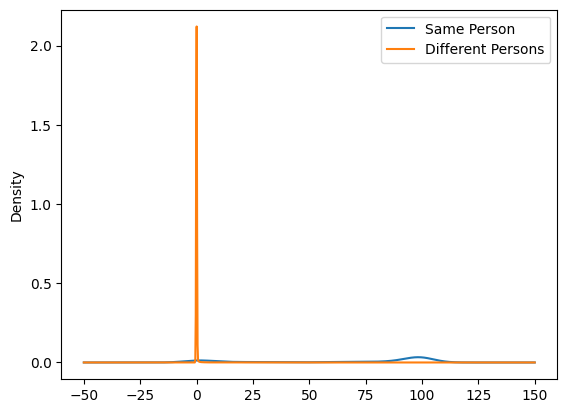

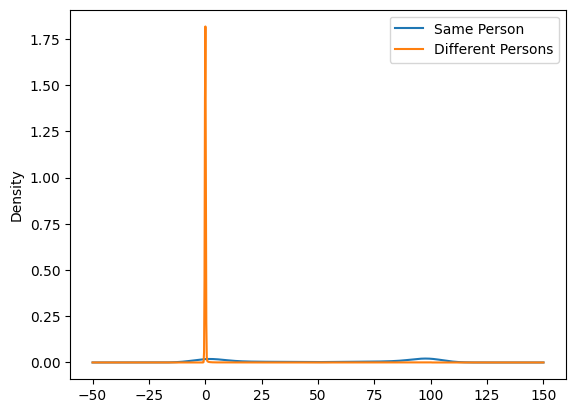

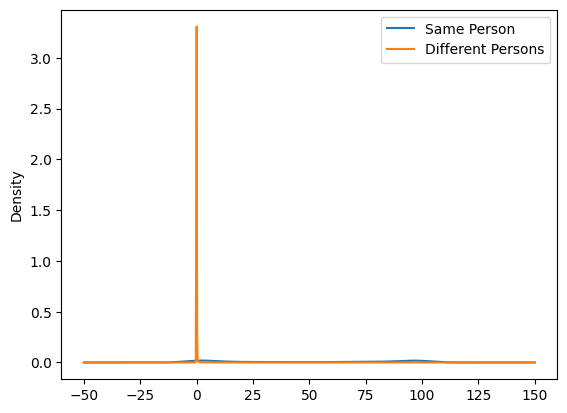

In [ ]:
for distance_metric in distance_metrics:
    df[df.actual == "Same Person"][f"{distance_metric}_confidence"].plot.kde(label="Same Person")
    df[df.actual == "Different Persons"][f"{distance_metric}_confidence"].plot.kde(label="Different Persons")
    plt.legend()
    plt.show()